In [1]:
from pathlib import Path
import sys
import torchaudio
import os
ROOT_DIR = Path.cwd().parent
os.chdir(ROOT_DIR)
sys.path.insert(0, str(ROOT_DIR / 'src' / 'models' / 'tacotron2_vae'))
from layers import TacotronSTFT



/home/richard/project/ml2_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
audio_waveform, sample_rate = torchaudio.load("data/raw/tts-portuguese-Corpora/TTS-Portuguese-Corpus/wavs/sample-1.wav")



In [3]:
stft = TacotronSTFT(
    filter_length=1024,
    hop_length=256,
    win_length=1024,
    sampling_rate=22050,
    mel_fmin=0.0,
    mel_fmax=8000.0
)

mel_spectrogram = stft.mel_spectrogram(audio_waveform)


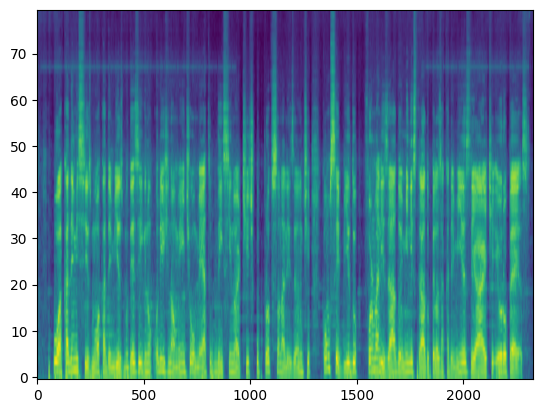

In [4]:
import matplotlib.pyplot as plt
plt.imshow(mel_spectrogram.squeeze().numpy(), origin='lower', aspect='auto')

In [5]:
from IPython.display import Audio
Audio(audio_waveform.numpy(), rate=sample_rate)


In [ ]:
inferred_audio = stft.griffin_lim(mel_spectrogram)

In [13]:
audio_inverted = torchaudio.transforms.InverseMelScale(
    1024,
    n_mels=80,
    sample_rate=22050,
    f_min=0.0,
    f_max=8000.0
)(mel_spectrogram)

In [ ]:
import torchaudio.transforms as T

# 1. Configurar o conversor de Escala Mel para Escala Linear
inverse_mel_scale = T.InverseMelScale(
    n_stft=1024 // 2 + 1,  # 513 (o que a STFT espera)
    n_mels=80,             # A dimensão atual do seu mel_spectrogram
    sample_rate=sample_rate, # A mesma taxa de amostragem do seu projeto
    driver='gelsd'          
)

# 2. Configurar o algoritmo de inversão (GriffinLim)
griffin_lim = T.GriffinLim(
    n_fft=1024,
    hop_length=256,
    win_length=1024,
    power=2
)

# 3. Executar a cadeia de conversão
# Passo A: Transforma de 80 canais (Mel) para 513 canais (Linear)
linear_spectrogram = inverse_mel_scale(mel_spectrogram)

# Passo B: Transforma os 513 canais de volta em áudio no domínio do tempo
audio_inverted_time = griffin_lim(linear_spectrogram)


In [25]:
audio_inverted_time.shape

torch.Size([1, 595968])

In [26]:
Audio(audio_inverted_time.numpy(), rate=sample_rate)